In [5]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

base = repo_root / "output" / "ner_conll2003_bert"

# --- Path templates ---
# Manifold certify
manifold_last = base / "certify" / "last" / "euclidean" / "annoy" / "annoy_index.ann"
manifold_layer = lambda l: base / "certify" / f"layer_{l}" / "euclidean" / "annoy" / "annoy_index.ann"

# Isotropic certify
iso_last = base / "isotropic_certify" / "last"
iso_layer = lambda l: base / "isotropic_certify" / f"layer_{l}"

# Masked manifold certify
masked_manifold = lambda mode: base / "masked_certify" / "last" / "euclidean" / "annoy" / "annoy_index.ann" / mode

# Isotropic masked certify
iso_masked = lambda mode: base / "isotropic_masked_certify" / "last" / mode

SIGMAS_ALL = ["sigma_0_25", "sigma_0_50", "sigma_0_75", "sigma_1_00"]
SIGMAS_MASK = ["sigma_0_25", "sigma_0_50", "sigma_0_75", "sigma_1_00"]
LAYERS = [0, 3, 6, 9]
LABEL_ORDER = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]
ENTITY_ORDER = ["O", "PER", "ORG", "LOC", "MISC"]

def sigma_val(s):
    return float(s.replace("sigma_", "").replace("_", "."))

def load_metrics(folder):
    """Load metrics.json or running_metrics.json from a folder."""
    if not folder.exists():
        return None
    for name in ["metrics.json", "running_metrics.json"]:
        p = folder / name
        if p.exists():
            with open(p) as f:
                data = json.load(f)
            if name == "running_metrics.json":
                return {"_status": "running", "_raw": data}
            return data
    return None

def extract_smooth(m):
    """Extract smoothed metrics dict from either completed or running format."""
    if m is None:
        return None
    if m.get("_status") == "running":
        return m["_raw"]["running"]
    return m.get("smoothed", {})

def extract_clean(m):
    if m is None or m.get("_status") == "running":
        return None
    return m.get("clean", {})

def row_from_smooth(s, sigma, label=""):
    """Build a summary row dict from smoothed metrics."""
    if s is None:
        return None
    return {
        "sigma": sigma,
        "label": label,
        "f1": s.get("f1", 0),
        "token_acc": s.get("token_acc", 0),
        "certified_acc": s.get("certified_token_acc", 0),
        "certified_correct": s.get("certified_correct_tokens", 0),
        "total_tokens": s.get("total_certified_tokens", 0),
        "mean_radius": s.get("mean_certified_radius", 0),
        "abstention_rate": s.get("abstention_rate", 0),
        "sentences": s.get("sentences_evaluated", 0),
        "samples_per_token": s.get("noisy_samples_per_token", 0),
    }

print("Setup complete. Repo root:", repo_root)

Setup complete. Repo root: /BS/dniazi_thesis/work/RandomizedSmothingmanifold


---
## 1. Isotropic vs Manifold — Last Layer, Multiple σ

In [6]:
rows = []
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)
    # Manifold
    m = load_metrics(manifold_last / sig)
    s = extract_smooth(m)
    r = row_from_smooth(s, sv, "Manifold")
    if r: rows.append(r)
    # Isotropic
    m = load_metrics(iso_last / sig)
    s = extract_smooth(m)
    r = row_from_smooth(s, sv, "Isotropic")
    if r: rows.append(r)

if rows:
    df = pd.DataFrame(rows)
    print("=" * 100)
    print("ISOTROPIC vs MANIFOLD — Last Layer")
    print("=" * 100)
    display(df.pivot_table(
        index='sigma',
        columns='label',
        values=['certified_acc', 'mean_radius', 'abstention_rate', 'f1'],
        aggfunc='first'
    ).round(4))
else:
    print("No results found yet. Copy results first.")

ISOTROPIC vs MANIFOLD — Last Layer


,abstention_rate,certified_acc,f1,mean_radius
label,Isotropic,Isotropic,Isotropic,Isotropic
sigma,,,,
0.25,0.0001,0.9794,0.8895,0.3750
0.50,0.0002,0.9794,0.8891,0.7495
0.75,0.0004,0.9794,0.8885,1.1238
1.00,0.0005,0.9794,0.8881,1.4979


In [8]:
m

{'experiment': {'name': 'ner-iso-last_sigma_1_00',
  'config_path': '/BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/sweep_configs/ner-iso-last_sigma_1_00.yaml',
  'checkpoint': '/BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/ner_conll2003_bert/ner_bert_conll2003_finetune/model.pt',
  'output_dir': 'output/ner_conll2003_bert/isotropic_certify/last/sigma_1_00'},
 'checkpoint': '/BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/ner_conll2003_bert/ner_bert_conll2003_finetune/model.pt',
 'split': 'test',
 'clean': {'loss': 0.21548126567978743,
  'precision': 0.8837844549292277,
  'recall': 0.8935475772031133,
  'f1': 0.8886392009987516,
  'token_acc': 0.9794862118230585,
  'masked_tokens': 0,
  'masked_sentences': 0},
 'smoothed': {'precision': 0.8824987605354487,
  'recall': 0.8937986442380116,
  'f1': 0.8881127603841836,
  'token_acc': 0.9793514300347737,
  'certified_token_acc': 0.9793514300347737,
  'certified_correct_tokens': 36331,
  'mean_certified_radius':

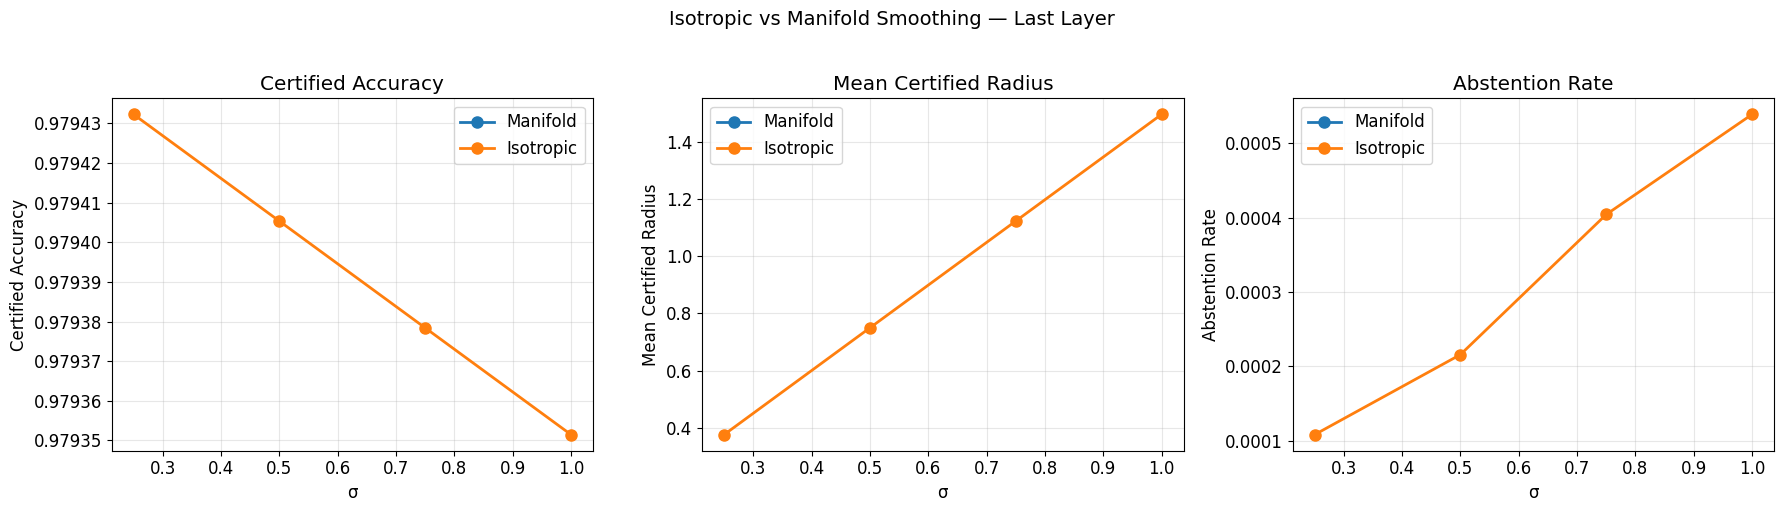

In [9]:
# Plot: Isotropic vs Manifold
if rows:
    df = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, metric, title in zip(axes, 
        ['certified_acc', 'mean_radius', 'abstention_rate'],
        ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']):
        for method in ['Manifold', 'Isotropic']:
            sub = df[df['label'] == method].sort_values('sigma')
            ax.plot(sub['sigma'], sub[metric], 'o-', label=method, linewidth=2, markersize=8)
        ax.set_xlabel('σ')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Isotropic vs Manifold Smoothing — Last Layer', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 2. Layer Comparison at σ = 0.50

In [11]:
layer_rows = []
sig = "sigma_0_50"
sv = 0.50

for method, path_fn in [("Manifold", lambda l: manifold_layer(l) / sig),
                         ("Isotropic", lambda l: iso_layer(l) / sig)]:
    # Last layer
    last_path = manifold_last / sig if method == "Manifold" else iso_last / sig
    m = load_metrics(last_path)
    s = extract_smooth(m)
    r = row_from_smooth(s, sv, method)
    if r:
        r['layer'] = 'last'
        layer_rows.append(r)
    
    # Other layers
    for layer in LAYERS:
        m = load_metrics(path_fn(layer))
        s = extract_smooth(m)
        r = row_from_smooth(s, sv, method)
        if r:
            r['layer'] = f'layer_{layer}'
            layer_rows.append(r)

if layer_rows:
    df_layer = pd.DataFrame(layer_rows)
    print("=" * 100)
    print("LAYER COMPARISON at σ=0.50")
    print("=" * 100)
    display(df_layer.pivot_table(
        index='layer',
        columns='label',
        values=['certified_acc', 'mean_radius', 'abstention_rate', 'f1'],
        aggfunc='first'
    ).round(4))
else:
    print("No layer results found yet.")

LAYER COMPARISON at σ=0.50


,abstention_rate,certified_acc,f1,mean_radius
label,Isotropic,Isotropic,Isotropic,Isotropic
layer,,,,
last,0.0002,0.9794,0.8891,0.7495
layer_0,0.0138,0.9627,0.7724,0.7099
layer_3,0.0113,0.9634,0.7845,0.7223
layer_6,0.0056,0.9746,0.8567,0.7380
layer_9,0.0013,0.9789,0.8835,0.7477


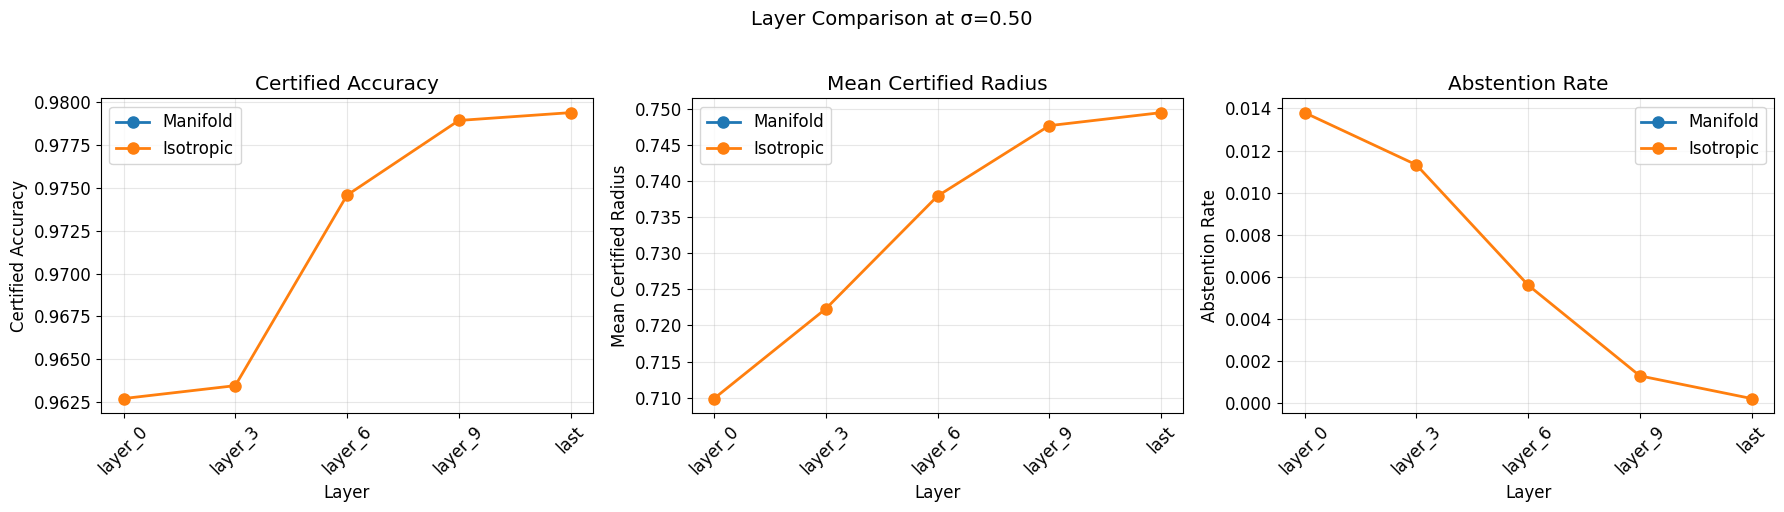

In [12]:
# Plot: Layer comparison
if layer_rows:
    df_layer = pd.DataFrame(layer_rows)
    layer_order = ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'last']
    df_layer['layer_rank'] = df_layer['layer'].map({l: i for i, l in enumerate(layer_order)})
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, title in zip(axes,
        ['certified_acc', 'mean_radius', 'abstention_rate'],
        ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']):
        for method in ['Manifold', 'Isotropic']:
            sub = df_layer[df_layer['label'] == method].sort_values('layer_rank')
            ax.plot(sub['layer'], sub[metric], 'o-', label=method, linewidth=2, markersize=8)
        ax.set_xlabel('Layer')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle('Layer Comparison at σ=0.50', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 3. Masking Context Mode at Last Layer, Multiple σ

In [ ]:
mask_rows = []
for sig in SIGMAS_MASK:
    sv = sigma_val(sig)
    for method, path in [("Manifold+Mask", masked_manifold("context") / sig),
                          ("Isotropic+Mask", iso_masked("context") / sig)]:
        m = load_metrics(path)
        s = extract_smooth(m)
        r = row_from_smooth(s, sv, method)
        if r: mask_rows.append(r)

if mask_rows:
    df_mask = pd.DataFrame(mask_rows)
    print("=" * 100)
    print("CONTEXT MASKING — Last Layer")
    print("=" * 100)
    display(df_mask.pivot_table(
        index='sigma',
        columns='label',
        values=['certified_acc', 'mean_radius', 'abstention_rate', 'f1'],
        aggfunc='first'
    ).round(4))
else:
    print("No masked results found yet.")

In [ ]:
# Plot: Masking context across sigma
if mask_rows:
    df_mask = pd.DataFrame(mask_rows)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, title in zip(axes,
        ['certified_acc', 'mean_radius', 'abstention_rate'],
        ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']):
        for method in df_mask['label'].unique():
            sub = df_mask[df_mask['label'] == method].sort_values('sigma')
            ax.plot(sub['sigma'], sub[metric], 'o-', label=method, linewidth=2, markersize=8)
        ax.set_xlabel('σ')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Context Masking — Last Layer', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 4. Masking Mode Comparison (Context / Entity / Hybrid) at σ=0.50

In [ ]:
mode_rows = []
sig = "sigma_0_50"
sv = 0.50

for mode in ["context", "entity", "hybrid"]:
    for method_label, path in [(f"Manifold+{mode}", masked_manifold(mode) / sig),
                                (f"Isotropic+{mode}", iso_masked(mode) / sig)]:
        m = load_metrics(path)
        s = extract_smooth(m)
        r = row_from_smooth(s, sv, method_label)
        if r: mode_rows.append(r)

if mode_rows:
    df_mode = pd.DataFrame(mode_rows)
    print("=" * 100)
    print("MASKING MODE COMPARISON at σ=0.50 — Last Layer")
    print("=" * 100)
    display(df_mode[['label', 'f1', 'certified_acc', 'mean_radius', 'abstention_rate', 
                      'certified_correct', 'total_tokens']].to_string(index=False))
else:
    print("No masking mode results found yet.")

In [ ]:
# Bar chart: masking mode comparison
if mode_rows:
    df_mode = pd.DataFrame(mode_rows)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['certified_acc', 'mean_radius', 'abstention_rate']
    titles = ['Certified Accuracy', 'Mean Certified Radius', 'Abstention Rate']
    
    for ax, metric, title in zip(axes, metrics, titles):
        df_mode.set_index('label')[metric].plot(kind='bar', ax=ax)
        ax.set_title(title)
        ax.set_ylabel(title)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Masking Mode Comparison at σ=0.50', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 5. Per-Label Certification Analysis

In [ ]:
def extract_label_breakdown(m):
    """Extract certification_by_label from metrics."""
    if m is None or m.get("_status") == "running":
        return None
    return m.get("smoothed", {}).get("certification_by_label", None)

def extract_entity_breakdown(m):
    if m is None or m.get("_status") == "running":
        return None
    return m.get("smoothed", {}).get("certification_by_entity", None)

# Per-label for manifold vs isotropic at σ=0.20
label_rows = []
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)
    for method, path in [("Manifold", manifold_last / sig), ("Isotropic", iso_last / sig)]:
        m = load_metrics(path)
        lbl = extract_label_breakdown(m)
        if lbl:
            for label in LABEL_ORDER:
                if label in lbl:
                    s = lbl[label]
                    label_rows.append({
                        'method': method,
                        'sigma': sv,
                        'label': label,
                        'total': s['total_tokens'],
                        'certified': s['certified_tokens'],
                        'correct': s['certified_correct_tokens'],
                        'cert_acc': s['certified_accuracy'],
                        'abstained': s['abstained_tokens'],
                        'abstention_rate': s['abstention_rate'],
                    })

if label_rows:
    df_lbl = pd.DataFrame(label_rows)
    print("=" * 100)
    print("PER-LABEL CERTIFICATION — Isotropic vs Manifold")
    print("=" * 100)
    
    for sig in df_lbl['sigma'].unique():
        print(f"\n--- σ = {sig} ---")
        sub = df_lbl[df_lbl['sigma'] == sig]
        pivot = sub.pivot_table(index='label', columns='method', 
                                values=['cert_acc', 'abstention_rate', 'total'], aggfunc='first')
        display(pivot.round(4))
else:
    print("No per-label results found yet.")

In [ ]:
# Per-entity grouped comparison at σ=0.20
entity_rows = []
for method, path in [("Manifold", manifold_last), ("Isotropic", iso_last)]:
    for sig in SIGMAS_ALL:
        sv = sigma_val(sig)
        m = load_metrics(path / sig)
        ent = extract_entity_breakdown(m)
        if ent:
            for entity in ENTITY_ORDER:
                if entity in ent:
                    s = ent[entity]
                    entity_rows.append({
                        'method': method,
                        'sigma': sv,
                        'entity': entity,
                        'total': s['total_tokens'],
                        'cert_acc': s['certified_accuracy'],
                        'abstention_rate': s['abstention_rate'],
                    })

if entity_rows:
    df_ent = pd.DataFrame(entity_rows)
    print("=" * 100)
    print("PER-ENTITY CERTIFICATION")
    print("=" * 100)
    pivot = df_ent.pivot_table(index=['sigma', 'entity'], columns='method', values='cert_acc', aggfunc='first')
    display(pivot.round(4))
else:
    print("No entity results found yet.")

---
## 6. Certified Radius Plots

In [ ]:
# Certified radius vs sigma — Isotropic vs Manifold
radius_rows = []
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)
    for method, path in [("Manifold", manifold_last / sig), ("Isotropic", iso_last / sig)]:
        m = load_metrics(path)
        s = extract_smooth(m)
        if s:
            radius_rows.append({'sigma': sv, 'method': method, 
                                'mean_radius': s.get('mean_certified_radius', 0),
                                'certified_acc': s.get('certified_token_acc', 0)})

if radius_rows:
    df_r = pd.DataFrame(radius_rows)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for method in df_r['method'].unique():
        sub = df_r[df_r['method'] == method].sort_values('sigma')
        axes[0].plot(sub['sigma'], sub['mean_radius'], 'o-', label=method, linewidth=2, markersize=8)
        axes[1].plot(sub['sigma'], sub['certified_acc'], 'o-', label=method, linewidth=2, markersize=8)
    
    axes[0].set_xlabel('σ'); axes[0].set_ylabel('Mean Certified Radius')
    axes[0].set_title('Mean Certified Radius vs σ'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('σ'); axes[1].set_ylabel('Certified Accuracy')
    axes[1].set_title('Certified Accuracy vs σ'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Certification Radius & Accuracy — Isotropic vs Manifold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No radius data found yet.")

In [ ]:
# Certified radius by layer at σ=0.50
layer_radius = []
sig = "sigma_0_50"

for method in ["Manifold", "Isotropic"]:
    # Last
    path = manifold_last / sig if method == "Manifold" else iso_last / sig
    m = load_metrics(path)
    s = extract_smooth(m)
    if s:
        layer_radius.append({'layer': 'last', 'method': method, 
                             'mean_radius': s.get('mean_certified_radius', 0),
                             'certified_acc': s.get('certified_token_acc', 0)})
    # Other layers
    for l in LAYERS:
        path = (manifold_layer(l) / sig) if method == "Manifold" else (iso_layer(l) / sig)
        m = load_metrics(path)
        s = extract_smooth(m)
        if s:
            layer_radius.append({'layer': f'layer_{l}', 'method': method,
                                 'mean_radius': s.get('mean_certified_radius', 0),
                                 'certified_acc': s.get('certified_token_acc', 0)})

if layer_radius:
    df_lr = pd.DataFrame(layer_radius)
    layer_order = ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'last']
    df_lr['rank'] = df_lr['layer'].map({l: i for i, l in enumerate(layer_order)})
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for method in df_lr['method'].unique():
        sub = df_lr[df_lr['method'] == method].sort_values('rank')
        axes[0].plot(sub['layer'], sub['mean_radius'], 'o-', label=method, linewidth=2, markersize=8)
        axes[1].plot(sub['layer'], sub['certified_acc'], 'o-', label=method, linewidth=2, markersize=8)
    
    axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Mean Certified Radius')
    axes[0].set_title('Certified Radius by Layer (σ=0.50)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Certified Accuracy')
    axes[1].set_title('Certified Accuracy by Layer (σ=0.50)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    for ax in axes: ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No layer radius data found yet.")

In [ ]:
# Per-entity certified accuracy heatmap at σ=0.20 (manifold)
m = load_metrics(manifold_last / "sigma_0_20")
ent = extract_entity_breakdown(m)

if ent:
    heatmap_data = {}
    for sig in SIGMAS_ALL:
        sv = sigma_val(sig)
        m = load_metrics(manifold_last / sig)
        e = extract_entity_breakdown(m)
        if e:
            heatmap_data[sv] = {entity: e[entity]['certified_accuracy'] for entity in ENTITY_ORDER if entity in e}
    
    if heatmap_data:
        df_heat = pd.DataFrame(heatmap_data).T
        df_heat.index.name = 'sigma'
        
        fig, ax = plt.subplots(figsize=(10, 5))
        im = ax.imshow(df_heat.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
        ax.set_xticks(range(len(df_heat.columns)))
        ax.set_xticklabels(df_heat.columns)
        ax.set_yticks(range(len(df_heat.index)))
        ax.set_yticklabels([f'σ={s}' for s in df_heat.index])
        
        for i in range(len(df_heat.index)):
            for j in range(len(df_heat.columns)):
                ax.text(j, i, f'{df_heat.values[i,j]:.2%}', ha='center', va='center', fontsize=10)
        
        plt.colorbar(im, label='Certified Accuracy')
        ax.set_title('Manifold: Certified Accuracy by Entity & σ')
        plt.tight_layout()
        plt.show()
else:
    print("No entity data found yet.")

---
## 8. Certified Volume Analysis — 4-Quantity Framework

| Qty | Formula | Source | Meaning |
|-----|---------|--------|---------|
| 1 | $C_D \cdot r_{iso}^D$ | Iso run | Classical RS volume (ambient D) |
| 2 | $C_k \cdot r_{iso}^k$ | Cross-ref | Fair semantic baseline (dim k) |
| 3 | $C_k \cdot r_{iso}^k \cdot \sqrt{\det\Lambda}$ | Cross-ref | Geometry-only gain (uses r_iso) |
| 4 | $C_k \cdot r_{mani}^k \cdot \sqrt{\det\Lambda}$ | Mani run | Actual manifold certificate |

- **Geometry factor** = $\frac{1}{2}\sum_i \log\lambda_i$ = log(Qty3/Qty2) — r-independent, pure eigenvalue advantage
- Qty 2 & 3 require cross-referencing both runs (computed below when both available)

In [ ]:
# 8a. All 4 Volume Quantities vs σ
volume_rows = []
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)
    for method, path in [("Manifold", manifold_last / sig), ("Isotropic", iso_last / sig)]:
        m = load_metrics(path)
        if m and "volume" in m:
            vol = m["volume"]
            volume_rows.append({
                'sigma': sv, 'method': method,
                'mean_log_vol_iso_D': vol.get('mean_log_vol_iso_D'),        # Qty 1
                'mean_log_vol_iso_k': vol.get('mean_log_vol_iso_k'),        # Qty 2
                'mean_log_vol_mani_pred': vol.get('mean_log_vol_mani_pred'), # Qty 3
                'mean_log_vol_mani_actual': vol.get('mean_log_vol_mani_actual'),  # Qty 4
                'mean_geometry_factor': vol.get('mean_geometry_factor'),
                'mean_effective_rank': vol.get('mean_effective_rank'),
                'k_pca': vol.get('k_pca'),
                'ambient_D': vol.get('ambient_D'),
            })

if volume_rows:
    df_vol = pd.DataFrame(volume_rows)
    mani = df_vol[df_vol['method'] == 'Manifold'].sort_values('sigma')
    iso = df_vol[df_vol['method'] == 'Isotropic'].sort_values('sigma')
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: All 4 quantities vs σ (all at dim k for fair comparison)
    if not mani.empty:
        axes[0].plot(mani['sigma'], mani['mean_log_vol_mani_actual'], 'o-',
                     label='Qty4: V_mani,actual', linewidth=2, color='tab:blue')
        if mani['mean_log_vol_mani_pred'].notna().any():
            axes[0].plot(mani['sigma'], mani['mean_log_vol_mani_pred'], 's--',
                         label='Qty3: V_mani,pred (r_iso)', linewidth=2, color='tab:cyan')
        if mani['mean_log_vol_iso_k'].notna().any():
            axes[0].plot(mani['sigma'], mani['mean_log_vol_iso_k'], '^:',
                         label='Qty2: V_iso,k (r_iso)', linewidth=1.5, color='tab:green', alpha=0.7)
    if not iso.empty and iso['mean_log_vol_iso_D'].notna().any():
        axes[0].plot(iso['sigma'], iso['mean_log_vol_iso_D'], 'v-',
                     label='Qty1: V_iso,D (ambient)', linewidth=1.5, color='tab:orange')
    axes[0].set_xlabel('σ'); axes[0].set_ylabel('Mean Log Volume')
    axes[0].set_title('All 4 Certified Volumes vs σ'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Geometry factor (r-independent)
    if not mani.empty:
        axes[1].plot(mani['sigma'], mani['mean_geometry_factor'], 'o-', linewidth=2, color='tab:green')
        axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('σ'); axes[1].set_ylabel('0.5·Σlog(λ_i)')
    axes[1].set_title('Geometry Factor (r-independent)'); axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Effective rank vs σ
    if not mani.empty:
        axes[2].plot(mani['sigma'], mani['mean_effective_rank'], 'o-', linewidth=2, color='tab:purple')
    axes[2].set_xlabel('σ'); axes[2].set_ylabel('Effective Rank')
    axes[2].set_title('Effective PCA Rank vs σ'); axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('NER — 4-Quantity Certified Volume Analysis (Last Layer)', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()
    
    # Summary table
    cols = ['method', 'sigma', 'k_pca', 'ambient_D',
            'mean_log_vol_iso_D', 'mean_log_vol_iso_k',
            'mean_log_vol_mani_pred', 'mean_log_vol_mani_actual',
            'mean_geometry_factor', 'mean_effective_rank']
    available_cols = [c for c in cols if c in df_vol.columns]
    print("\n4-Quantity Volume Summary:")
    display(df_vol[available_cols].round(2))
else:
    print("No volume data found yet. Run experiments with updated code first.")

In [ ]:
# 8b. Eigenvalue Spectrum — sample from last layer manifold run
eigen_path = manifold_last / "sigma_0_50" / "eigenvalues.npz"

if eigen_path.exists():
    data = np.load(eigen_path)
    mean_evals = data.get('mean_eigenvalues', data.get('eigenvalues', np.array([])))
    if mean_evals.ndim == 2:
        mean_evals = mean_evals.mean(axis=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    k = len(mean_evals)
    # Plot 1: Eigenvalue spectrum (log scale)
    axes[0].semilogy(range(k), np.sort(mean_evals)[::-1], linewidth=2)
    axes[0].set_xlabel('PCA Component'); axes[0].set_ylabel('Eigenvalue (log)')
    axes[0].set_title(f'Mean Eigenvalue Spectrum (k={k})')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Cumulative variance explained
    sorted_evals = np.sort(mean_evals)[::-1]
    cumvar = np.cumsum(sorted_evals) / sorted_evals.sum()
    axes[1].plot(range(k), cumvar, linewidth=2)
    axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95%')
    axes[1].axhline(0.99, color='orange', linestyle='--', alpha=0.7, label='99%')
    axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Variance')
    axes[1].set_title('Cumulative Variance Explained')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Geometry factor vs k (how log_det_half grows with more components)
    log_det_halfs = [0.5 * np.sum(np.log(np.maximum(sorted_evals[:i+1], 1e-30))) for i in range(k)]
    axes[2].plot(range(1, k+1), log_det_halfs, linewidth=2, color='tab:red')
    axes[2].set_xlabel('k (PCA components)'); axes[2].set_ylabel('0.5 × Σ log(λ_i)')
    axes[2].set_title('Geometry Factor vs k')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Eigenvalue Analysis — NER σ=0.50 Last Layer', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print diagnostics
    from src.certify.randomized import eigenvalue_diagnostics
    diag = eigenvalue_diagnostics(mean_evals)
    print(f"k={diag.k}, effective_rank={diag.effective_rank:.1f}, "
          f"condition_number={diag.condition_number:.1f}, "
          f"λ_max={diag.lambda_max:.4f}, λ_min={diag.lambda_min:.6f}")
else:
    print(f"No eigenvalues file at {eigen_path}. Run manifold experiment with updated code.")

In [ ]:
# 8c. Volume by Layer at σ=0.50
layer_vol = []
sig = "sigma_0_50"

for method in ["Manifold", "Isotropic"]:
    # Last layer
    path = manifold_last / sig if method == "Manifold" else iso_last / sig
    m = load_metrics(path)
    if m and "volume" in m:
        layer_vol.append({'layer': 'last', 'method': method, **m['volume']})
    # Other layers
    for l in LAYERS:
        path = (manifold_layer(l) / sig) if method == "Manifold" else (iso_layer(l) / sig)
        m = load_metrics(path)
        if m and "volume" in m:
            layer_vol.append({'layer': f'layer_{l}', 'method': method, **m['volume']})

if layer_vol:
    df_lv = pd.DataFrame(layer_vol)
    layer_order = ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'last']
    df_lv['rank'] = df_lv['layer'].map({l: i for i, l in enumerate(layer_order)})
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    mani_sub = df_lv[df_lv['method'] == 'Manifold'].sort_values('rank')
    iso_sub = df_lv[df_lv['method'] == 'Isotropic'].sort_values('rank')
    
    # Plot 1: Qty 4 (mani) vs Qty 1 (iso) by layer
    if not mani_sub.empty and 'mean_log_vol_mani_actual' in mani_sub.columns:
        axes[0].plot(mani_sub['layer'], mani_sub['mean_log_vol_mani_actual'], 'o-',
                     label='Qty4: V_mani,actual', linewidth=2, markersize=8, color='tab:blue')
    if not iso_sub.empty and 'mean_log_vol_iso_D' in iso_sub.columns:
        axes[0].plot(iso_sub['layer'], iso_sub['mean_log_vol_iso_D'], '^-',
                     label='Qty1: V_iso,D', linewidth=2, markersize=8, color='tab:orange')
    # Also Qty 2 & 3 if available
    if not mani_sub.empty and 'mean_log_vol_iso_k' in mani_sub.columns and mani_sub['mean_log_vol_iso_k'].notna().any():
        axes[0].plot(mani_sub['layer'], mani_sub['mean_log_vol_iso_k'], 's--',
                     label='Qty2: V_iso,k', linewidth=1.5, color='tab:green', alpha=0.7)
    axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Mean Log Volume')
    axes[0].set_title('Log Volume by Layer (σ=0.50)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Geometry factor by layer
    if not mani_sub.empty and 'mean_geometry_factor' in mani_sub.columns:
        axes[1].bar(mani_sub['layer'], mani_sub['mean_geometry_factor'], color='tab:green', alpha=0.7)
        axes[1].axhline(0, color='gray', linestyle='--')
    axes[1].set_xlabel('Layer'); axes[1].set_ylabel('0.5·Σlog(λ_i)')
    axes[1].set_title('Geometry Factor by Layer'); axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Effective rank by layer
    if not mani_sub.empty and 'mean_effective_rank' in mani_sub.columns:
        axes[2].bar(mani_sub['layer'], mani_sub['mean_effective_rank'], color='tab:purple', alpha=0.7)
    axes[2].set_xlabel('Layer'); axes[2].set_ylabel('Effective Rank')
    axes[2].set_title('Effective PCA Rank by Layer'); axes[2].grid(True, alpha=0.3)
    
    for ax in axes: ax.tick_params(axis='x', rotation=45)
    plt.suptitle('NER — Volume Analysis by Layer (σ=0.50)', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()
    
    # Summary table
    cols = ['layer', 'method', 'k_pca', 'mean_log_vol_iso_D', 'mean_log_vol_iso_k',
            'mean_log_vol_mani_pred', 'mean_log_vol_mani_actual', 'mean_geometry_factor', 'mean_effective_rank']
    available_cols = [c for c in cols if c in df_lv.columns]
    print("\nLayer Volume Summary:")
    display(df_lv[available_cols].sort_values(['method', 'rank']).round(2))
else:
    print("No layer volume data found yet.")

---
## 7. Summary Table — All Experiments

In [ ]:
# Grand summary of all experiments
all_rows = []

# Manifold & Isotropic last layer
for sig in SIGMAS_ALL:
    sv = sigma_val(sig)
    for tag, path in [("Manifold/last", manifold_last / sig), ("Isotropic/last", iso_last / sig)]:
        m = load_metrics(path)
        s = extract_smooth(m)
        r = row_from_smooth(s, sv, tag)
        if r:
            r['experiment'] = tag
            all_rows.append(r)

# Layers at σ=0.50
for l in LAYERS:
    for tag, path in [(f"Manifold/layer_{l}", manifold_layer(l) / "sigma_0_50"),
                       (f"Isotropic/layer_{l}", iso_layer(l) / "sigma_0_50")]:
        m = load_metrics(path)
        s = extract_smooth(m)
        r = row_from_smooth(s, 0.50, tag)
        if r:
            r['experiment'] = tag
            all_rows.append(r)

# Masking
for mode in ["context", "entity", "hybrid"]:
    sigs = SIGMAS_MASK if mode == "context" else ["sigma_0_50"]
    for sig in sigs:
        sv = sigma_val(sig)
        for tag, path in [(f"Manifold+{mode}", masked_manifold(mode) / sig),
                           (f"Isotropic+{mode}", iso_masked(mode) / sig)]:
            m = load_metrics(path)
            s = extract_smooth(m)
            r = row_from_smooth(s, sv, tag)
            if r:
                r['experiment'] = tag
                all_rows.append(r)

if all_rows:
    df_all = pd.DataFrame(all_rows)
    print("=" * 120)
    print("GRAND SUMMARY — ALL EXPERIMENTS")
    print("=" * 120)
    display(df_all[['experiment', 'sigma', 'f1', 'certified_acc', 'mean_radius', 
                     'abstention_rate', 'certified_correct', 'total_tokens', 'sentences']].round(4))
else:
    print("No results found yet. Copy server results first.")

---
## 10. Per-Token Vote Distribution (from debug_neighbors.json)
Visualize how the 100 noisy samples voted for each token — certified tokens (green) vs abstained tokens (red).

In [ ]:
# 10a. Load debug_neighbors.json and plot vote distributions
import json
import matplotlib.pyplot as plt

# Pick a specific experiment to visualize
TARGET_LAYER = "last"       # "last", "layer_0", "layer_3", etc.
TARGET_SIGMA = "sigma_0_50"
TARGET_MODE = "manifold_certify"  # "manifold_certify" or "isotropic_certify"

debug_path = certify_dir / TARGET_MODE / TARGET_LAYER / TARGET_SIGMA / "debug_neighbors.json"
if not debug_path.exists():
    # Try alternate path structure
    debug_path = certify_dir / TARGET_LAYER / TARGET_SIGMA / "debug_neighbors.json"

if debug_path.exists():
    with open(debug_path) as f:
        debug_data = json.load(f)
    
    examples = debug_data.get("examples", debug_data if isinstance(debug_data, list) else [])
    
    # Collect all tokens with vote info
    all_tokens = []
    for ex in examples:
        for tok in (ex.get("token_debug") or []):
            vote_rows = tok.get("vote_top5", [])
            if not vote_rows:
                continue
            top_count = int(vote_rows[0]["count"]) if vote_rows else 0
            second_count = int(vote_rows[1]["count"]) if len(vote_rows) > 1 else 0
            all_tokens.append({
                "token": tok["token"],
                "true_label": tok.get("true_label", "?"),
                "certified": tok.get("certified", False),
                "radius": tok.get("certified_radius", 0.0),
                "votes": vote_rows,
                "margin": top_count - second_count,
                "pred": tok.get("pred_label_majority_vote", "?"),
            })
    
    # Pick tokens: 6 certified (highest margin) + 6 abstained (lowest margin)
    certified = sorted([t for t in all_tokens if t["certified"]], key=lambda x: -x["margin"])
    abstained = sorted([t for t in all_tokens if not t["certified"]], key=lambda x: x["margin"])
    selected = certified[:6] + abstained[:6]
    if not selected:
        selected = all_tokens[:12]
    
    n = len(selected)
    if n > 0:
        cols = min(4, n)
        rows_plot = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows_plot, cols, figsize=(5 * cols, 4 * rows_plot), squeeze=False)
        
        for idx, tok in enumerate(selected):
            ax = axes[idx // cols][idx % cols]
            labels = [r["label"] for r in tok["votes"]]
            counts = [int(r["count"]) for r in tok["votes"]]
            color = '#4daf4a' if tok["certified"] else '#e41a1c'
            ax.bar(labels, counts, color=color, alpha=0.8, edgecolor='k')
            status = f"✓ r={tok['radius']:.3f}" if tok["certified"] else "✗ ABSTAIN"
            ax.set_title(f'"{tok["token"]}" [{tok["true_label"]}]\n{status}', fontsize=10)
            ax.set_ylabel("Votes (out of n)")
            ax.tick_params(axis='x', rotation=45, labelsize=8)
        
        # Hide unused axes
        for idx in range(n, rows_plot * cols):
            axes[idx // cols][idx % cols].set_visible(False)
        
        fig.suptitle(f"Vote Distribution — {TARGET_MODE} / {TARGET_LAYER} / σ={TARGET_SIGMA.replace('sigma_','').replace('_','.')}\n"
                     f"Certified (green) vs Abstained (red)", fontsize=13, y=1.01)
        fig.tight_layout()
        plt.show()
        
        # Print summary table
        print(f"\n{'Token':<15} {'True':<10} {'Pred':<10} {'Status':<12} {'Top Vote':<15} {'Margin'}")
        print("─" * 75)
        for tok in selected:
            top = tok['votes'][0]
            status = f"✓ r={tok['radius']:.3f}" if tok['certified'] else "✗ ABSTAIN"
            print(f"{tok['token']:<15} {tok['true_label']:<10} {tok['pred']:<10} {status:<12} "
                  f"{top['label']}:{top['count']:<8} {tok['margin']}")
    else:
        print("No tokens with vote data found in debug JSON")
else:
    print(f"No debug file at: {debug_path}")
    print("Available experiments:")
    for p in sorted(certify_dir.rglob("debug_neighbors.json")):
        print(f"  {p.relative_to(certify_dir)}")